<a href="https://colab.research.google.com/github/agysin22/CNN-for-Satellite-Imagery-Classification/blob/main/GEOG4003_FinalCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# Limit GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(f"Error enabling memory growth: {e}")


GPU memory growth enabled.


In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import json

In [ ]:
# Define the data directory
data_directory = r"C:\Users\agysi\OneDrive\Desktop\GEOG4003\FinalProjectData\Cityscape Dataset"
batch_size = 32
image_size = (128, 128)
epochs = 50
num_classes = 10

In [ ]:
# --- Step 1: Load All Image Paths and Labels ---
image_paths = []
image_labels = []

for class_name in os.listdir(data_directory):
    class_path = os.path.join(data_directory, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, image_file))
            image_labels.append(class_name)

In [ ]:
# Convert to DataFrame (easier to handle)
df = pd.DataFrame({
    'file_path': image_paths,
    'label': image_labels
})

In [ ]:
from sklearn.model_selection import train_test_split
# --- Step 2: Train-Test-Validation Split ---
# Step 2a: Split 80% Train, 20% Temp (for Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# Step 2b: Split the 20% Temp into 10% Validation, 10% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# Print Sizes of Each Split
print(f"Training set size: {len(train_df)} images")
print(f"Validation set size: {len(val_df)} images")
print(f"Test set size: {len(test_df)} images")

Training set size: 6400 images
Validation set size: 800 images
Test set size: 800 images


In [ ]:
# Define the different augmentation strategies
augmentation_strategies = {
    'base': ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2),
    'rotation': ImageDataGenerator(rescale=1.0/255.0, rotation_range=20, validation_split=0.2),
    'shift': ImageDataGenerator(rescale=1.0/255.0, width_shift_range=0.2, height_shift_range=0.2, validation_split=0.2),
    'zoom': ImageDataGenerator(rescale=1.0/255.0, zoom_range=0.2, validation_split=0.2),
    'flip': ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True, validation_split=0.2)
}

In [ ]:
# Early stopping callback - stop training if no improvement in validation loss after 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',   # Monitor validation loss
    patience=10,           # Number of epochs with no improvement to wait before stopping
    restore_best_weights=True  # Restore the best weights when stopping early
)

In [ ]:
from tensorflow.keras import models, layers, regularizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import numpy as np

# Dictionary to store model results
results = {}

# Define the callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for strategy_name, data_generator in augmentation_strategies.items():
    print(f"\n--- Training with {strategy_name} augmentation ---\n")

    # --- Train Generator (80%) ---
    train_generator = data_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='file_path',
        y_col='label',
        target_size=image_size,
        batch_size=batch_size,
        class_mode='sparse'
    )

    # --- Validation Generator (10%) ---
    val_generator = ImageDataGenerator(rescale=1.0/255.0).flow_from_dataframe(
        dataframe=val_df,
        x_col='file_path',
        y_col='label',
        target_size=image_size,
        batch_size=batch_size,
        class_mode='sparse'
    )

    # --- Test Generator (10%) ---
    test_generator = ImageDataGenerator(rescale=1.0/255.0).flow_from_dataframe(
        dataframe=test_df,
        x_col='file_path',
        y_col='label',
        target_size=image_size,
        batch_size=batch_size,
        class_mode='sparse',
        shuffle=False  # Don't shuffle to ensure consistent test results
    )

    # --- Define CNN Model ---
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(64, (3, 3),
                      kernel_regularizer=regularizers.l2(1e-5),
                      input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Second Convolutional Block
        layers.Conv2D(128, (3, 3),
                      kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Third Convolutional Block (Newly Added)
        layers.Conv2D(256, (3, 3),
                      kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten the output for the Fully Connected Layers
        layers.Flatten(),

        # Fully Connected Layers
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        layers.Dense(32, kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile the model with Adam optimizer and a learning rate of 1e-4
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Print model summary
    model.summary()

    # --- Train the Model ---
    print(f"\n🔍 Starting training for {strategy_name} strategy...\n")
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=1
    )

    print(f"\nTraining stopped early after {len(history.history['loss'])} epochs for {strategy_name} strategy.\n")

    # --- Evaluate the model on the **entire test set** ---
    print(f"\n📊 Evaluating model for {strategy_name} strategy on the test set...\n")
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
    print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}\n")

    # --- Collect predictions for the **entire test set** ---
    pred_classes = []
    true_classes = []

    for batch_images, batch_labels in test_generator:
        batch_predictions = model.predict(batch_images)
        pred_classes.extend(np.argmax(batch_predictions, axis=1))  # Predicted classes for this batch
        true_classes.extend(batch_labels)  # True labels for this batch

        # Ensure we only process the complete test set once
        if len(true_classes) >= test_generator.n:
            break

    # --- Store all the results for this strategy ---
    results[strategy_name] = {
        'history': history.history,
        'predictions': pred_classes,
        'true_classes': true_classes,
        'class_names': list(train_generator.class_indices.keys()),
        'test_loss': test_loss,
        'test_accuracy': test_accuracy
    }

    # --- Save the trained model for this strategy ---
    model.save(f'model_{strategy_name}.h5')
    print(f"✅ Model for {strategy_name} augmentation saved as 'model_{strategy_name}.h5'\n")

    # --- Save the training history and metrics ---
    print(f"📁 Saving training history and results for {strategy_name}...")
    np.save(f"history_{strategy_name}.npy", history.history)
    np.save(f"results_{strategy_name}.npy", results[strategy_name])



--- Training with base augmentation ---

Found 6400 validated image filenames belonging to 10 classes.
Found 800 validated image filenames belonging to 10 classes.
Found 800 validated image filenames belonging to 10 classes.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 64)      1792      
                                                                 
 batch_normalization (BatchN  (None, 126, 126, 64)     256       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 126, 126, 64)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 64)       0         
 )                                                               
                            


--- Evaluation for base augmentation ---


Classification Report for base
              precision    recall  f1-score   support

      Bridge       0.75      0.88      0.81        80
  Commercial       0.61      0.39      0.47        80
  Industrial       0.63      0.74      0.68        80
Intersection       0.80      0.59      0.68        80
    Landmark       0.53      0.45      0.49        80
        Park       0.77      0.66      0.71        80
     Parking       0.98      0.79      0.88        80
  Playground       0.71      0.74      0.72        80
 Residential       0.48      0.79      0.60        80
     Stadium       0.63      0.70      0.66        80

    accuracy                           0.67       800
   macro avg       0.69      0.67      0.67       800
weighted avg       0.69      0.67      0.67       800


Confusion Matrix for base


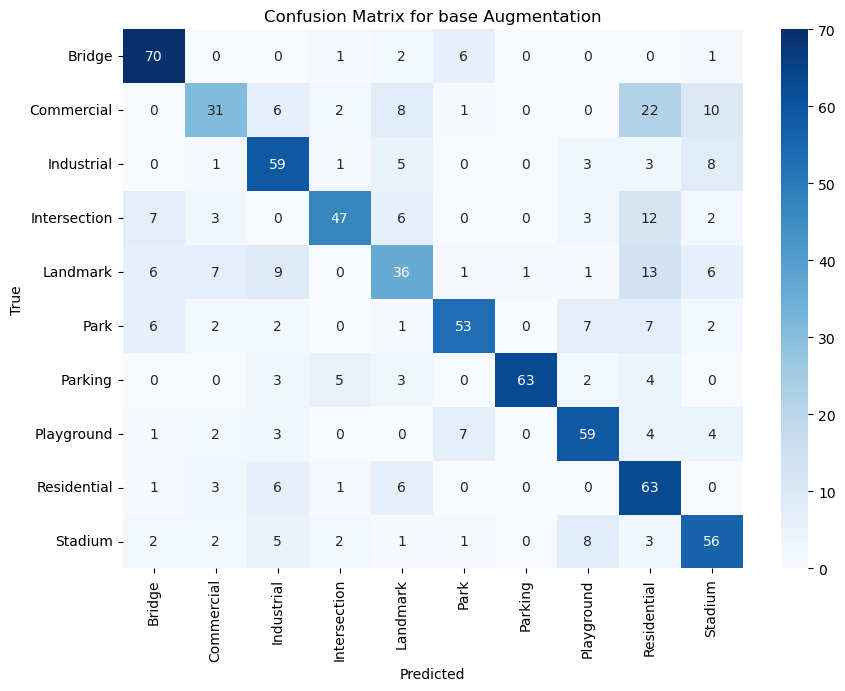

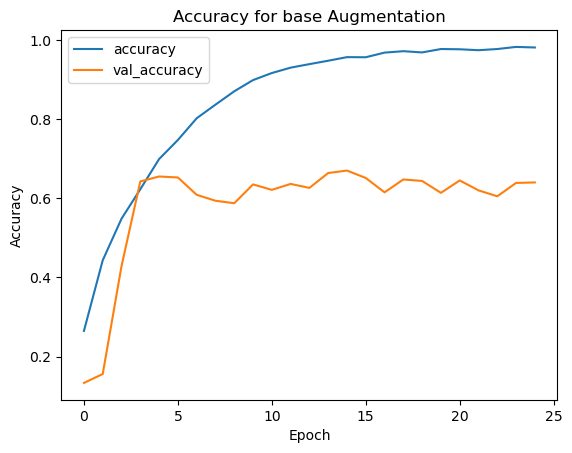

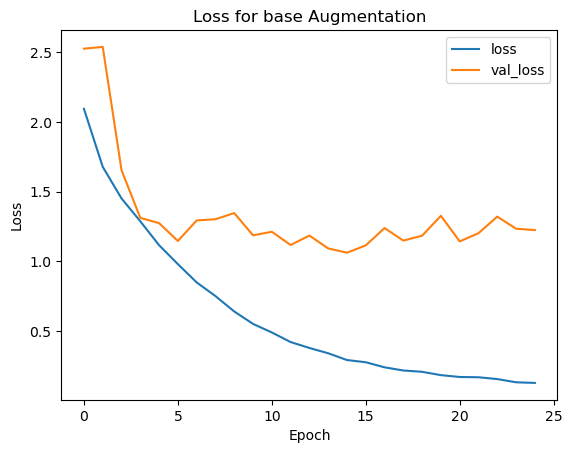


--- Evaluation for rotation augmentation ---


Classification Report for rotation
              precision    recall  f1-score   support

      Bridge       0.87      0.85      0.86        80
  Commercial       0.60      0.74      0.66        80
  Industrial       0.65      0.89      0.75        80
Intersection       0.88      0.75      0.81        80
    Landmark       0.54      0.54      0.54        80
        Park       0.76      0.80      0.78        80
     Parking       0.95      0.96      0.96        80
  Playground       0.89      0.68      0.77        80
 Residential       0.83      0.66      0.74        80
     Stadium       0.78      0.74      0.76        80

    accuracy                           0.76       800
   macro avg       0.77      0.76      0.76       800
weighted avg       0.77      0.76      0.76       800


Confusion Matrix for rotation


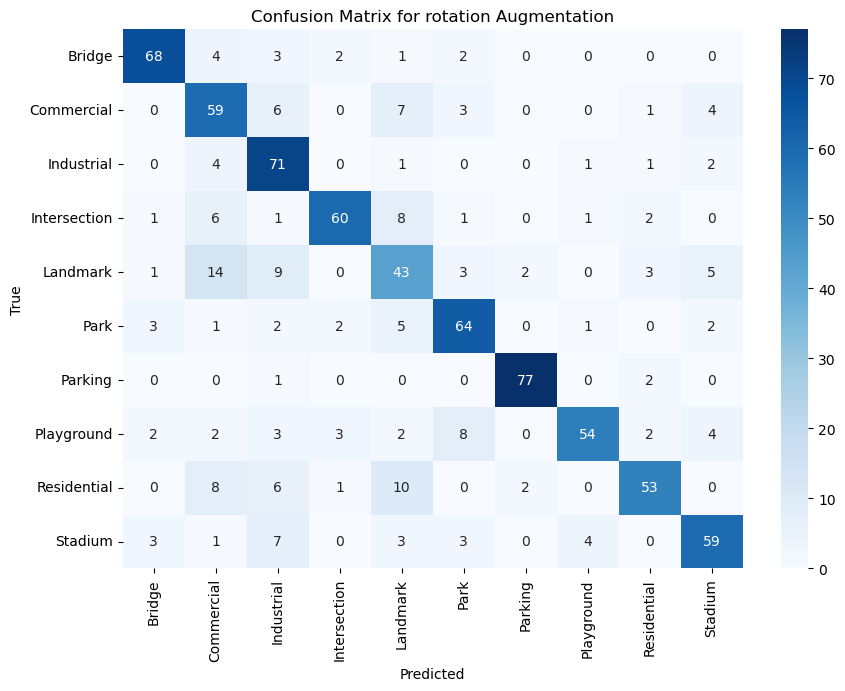

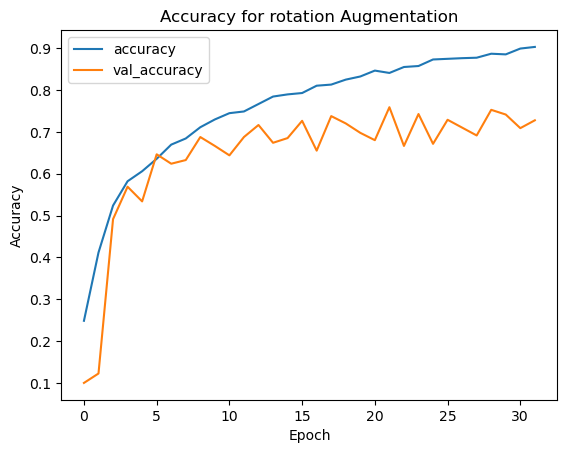

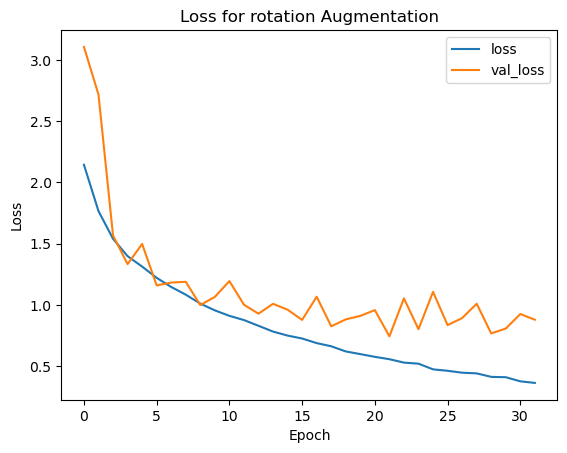


--- Evaluation for shift augmentation ---


Classification Report for shift
              precision    recall  f1-score   support

      Bridge       0.95      0.91      0.93        80
  Commercial       0.87      0.57      0.69        80
  Industrial       0.65      0.96      0.78        80
Intersection       0.96      0.69      0.80        80
    Landmark       0.79      0.60      0.68        80
        Park       0.78      0.91      0.84        80
     Parking       0.92      0.96      0.94        80
  Playground       0.85      0.82      0.84        80
 Residential       0.71      0.93      0.80        80
     Stadium       0.85      0.80      0.83        80

    accuracy                           0.82       800
   macro avg       0.83      0.82      0.81       800
weighted avg       0.83      0.82      0.81       800


Confusion Matrix for shift


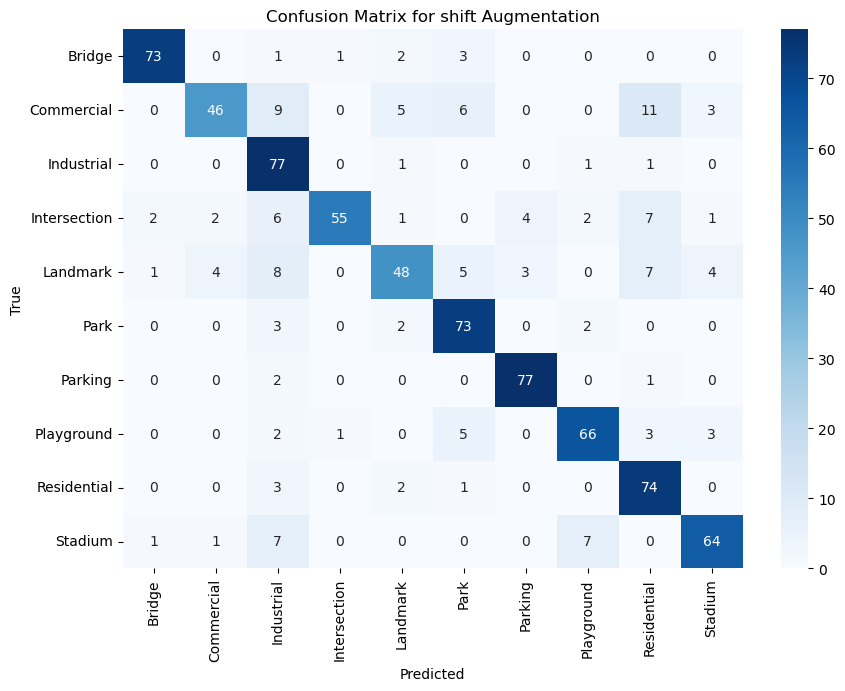

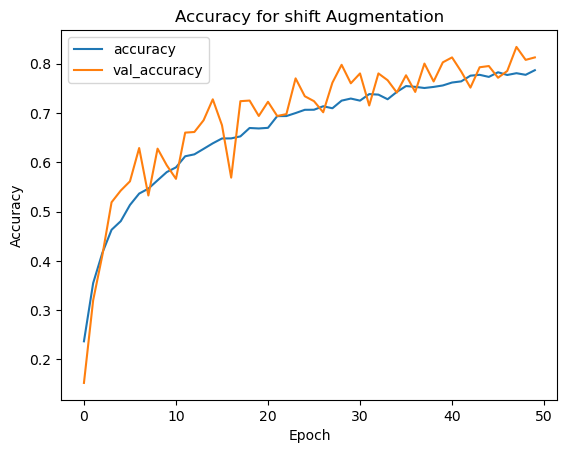

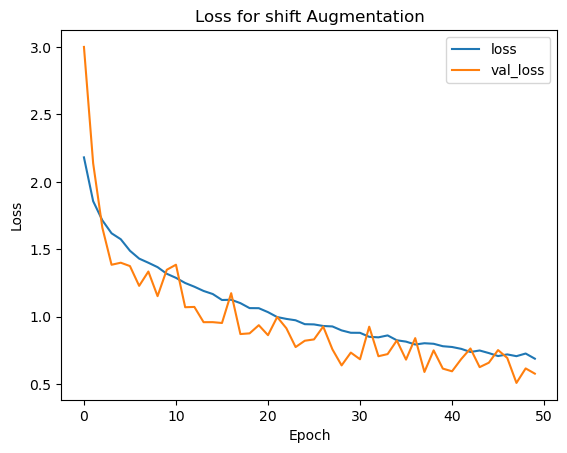


--- Evaluation for zoom augmentation ---


Classification Report for zoom
              precision    recall  f1-score   support

      Bridge       0.92      0.76      0.84        80
  Commercial       0.61      0.59      0.60        80
  Industrial       0.71      0.79      0.75        80
Intersection       0.78      0.70      0.74        80
    Landmark       0.60      0.39      0.47        80
        Park       0.84      0.71      0.77        80
     Parking       0.86      0.97      0.91        80
  Playground       0.90      0.70      0.79        80
 Residential       0.48      0.93      0.63        80
     Stadium       0.84      0.72      0.78        80

    accuracy                           0.73       800
   macro avg       0.75      0.73      0.73       800
weighted avg       0.75      0.73      0.73       800


Confusion Matrix for zoom


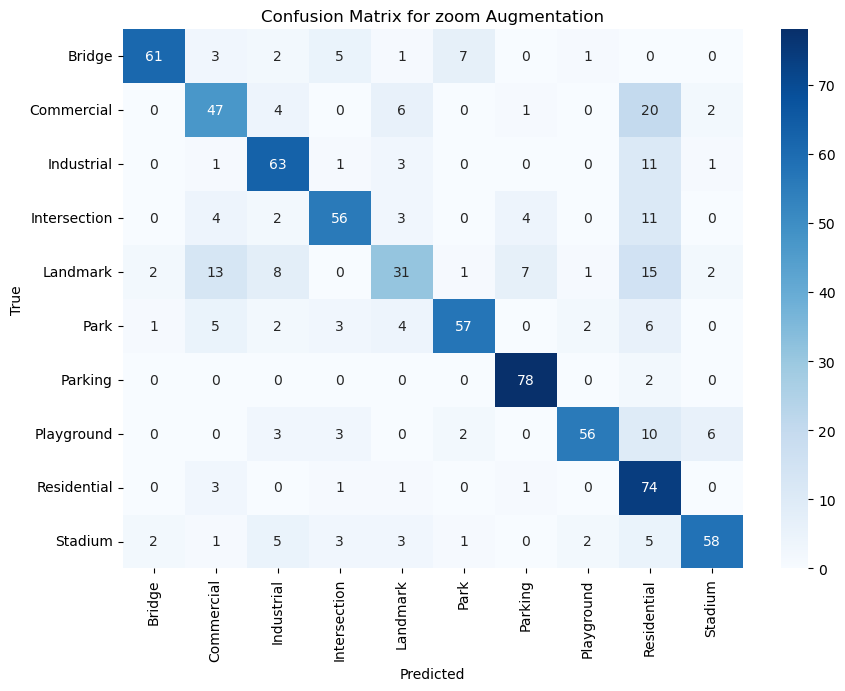

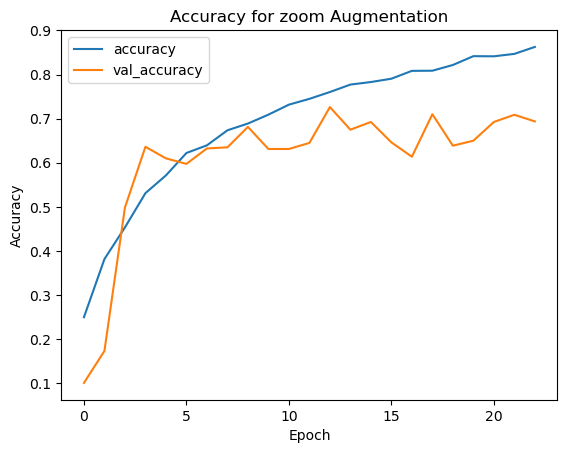

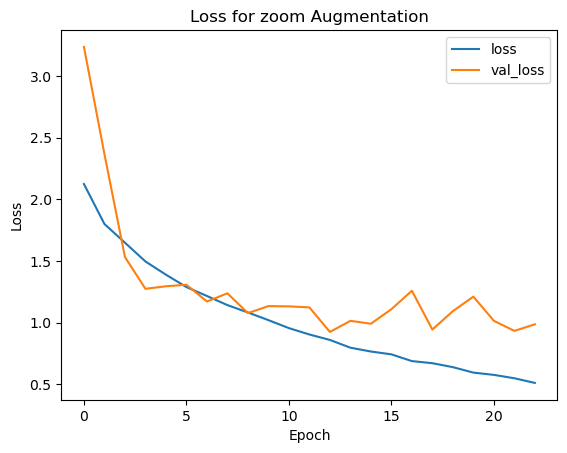


--- Evaluation for flip augmentation ---


Classification Report for flip
              precision    recall  f1-score   support

      Bridge       0.76      0.84      0.80        80
  Commercial       0.54      0.72      0.62        80
  Industrial       0.67      0.80      0.73        80
Intersection       0.79      0.70      0.74        80
    Landmark       0.67      0.38      0.48        80
        Park       0.71      0.84      0.77        80
     Parking       0.86      0.93      0.89        80
  Playground       0.81      0.57      0.67        80
 Residential       0.75      0.65      0.70        80
     Stadium       0.64      0.70      0.67        80

    accuracy                           0.71       800
   macro avg       0.72      0.71      0.71       800
weighted avg       0.72      0.71      0.71       800


Confusion Matrix for flip


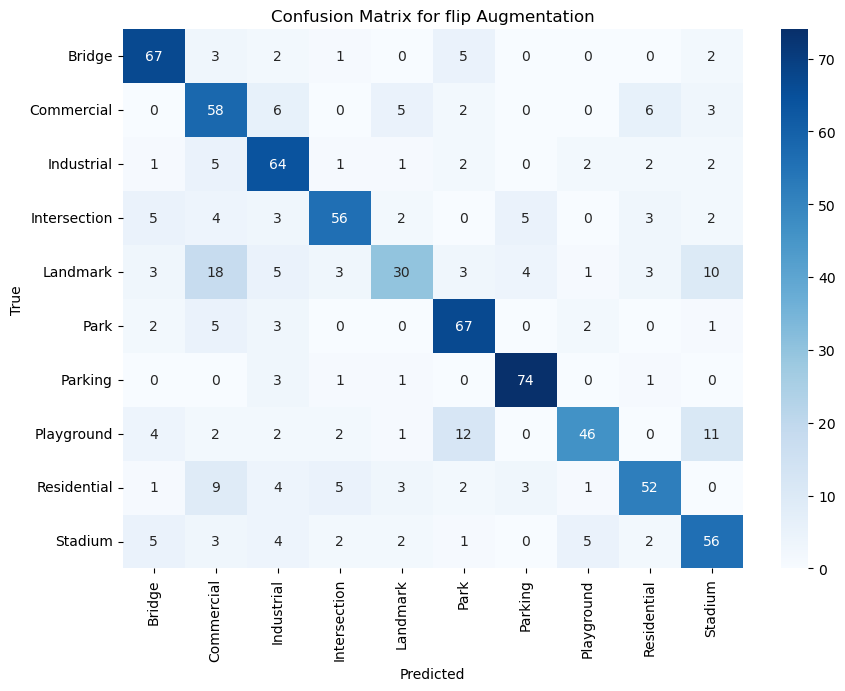

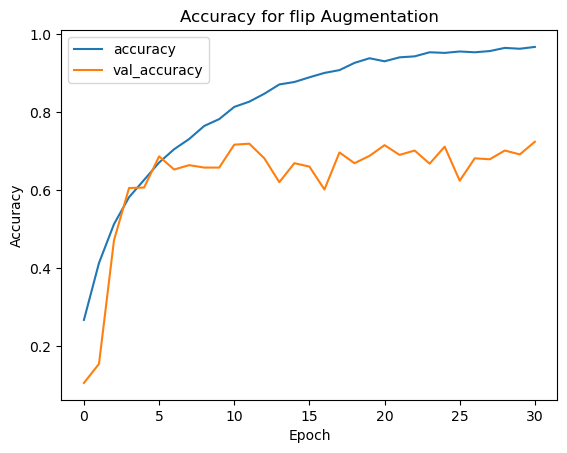

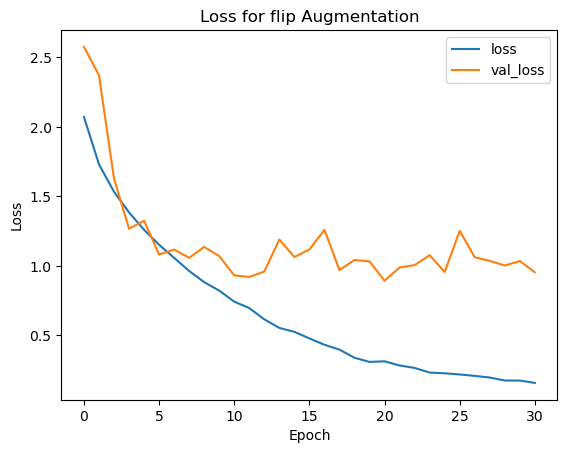

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Loop through each augmentation strategy's results
for strategy_name, result in results.items():
    print(f"\n--- Evaluation for {strategy_name} augmentation ---\n")

    # Extract data from results
    history = result['history']
    pred_classes = result['predictions']
    true_classes = result['true_classes']
    class_names = result['class_names']

    # Classification Report
    print("\nClassification Report for", strategy_name)
    class_report = classification_report(true_classes, pred_classes, target_names=class_names)
    print(class_report)

    # Confusion Matrix
    print("\nConfusion Matrix for", strategy_name)
    conf_matrix = confusion_matrix(true_classes, pred_classes)
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {strategy_name} Augmentation')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Accuracy Plot
    plt.figure()
    plt.plot(history['accuracy'], label='accuracy')
    plt.plot(history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy for {strategy_name} Augmentation')
    plt.legend()
    plt.show()

    # Loss Plot
    plt.figure()
    plt.plot(history['loss'], label='loss')
    plt.plot(history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss for {strategy_name} Augmentation')
    plt.legend()
    plt.show()


In [ ]:
# 📋 5. Summary of Overall Results
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# List to store the summary results
summary_results = []

# Loop through each augmentation strategy's results
for strategy_name, result in results.items():
    # Extract stored results
    test_loss = result['test_loss']
    test_accuracy = result['test_accuracy']
    pred_classes = np.array(result['predictions'])
    true_classes = np.array(result['true_classes'])

    # Calculate classification metrics
    class_report = classification_report(true_classes, pred_classes, output_dict=True)
    precision = class_report['macro avg']['precision']
    recall = class_report['macro avg']['recall']
    f1_score = class_report['macro avg']['f1-score']

    # Calculate confusion matrix, correct and incorrect predictions
    conf_matrix = confusion_matrix(true_classes, pred_classes)
    total_correct = np.trace(conf_matrix)  # Sum of diagonal elements
    total_incorrect = np.sum(conf_matrix) - total_correct  # Total minus correct predictions

    # Store results in summary list
    summary_results.append({
        'Augmentation Strategy': strategy_name,
        'Test Accuracy': round(test_accuracy, 4),
        'Test Loss': round(test_loss, 4),
        'Precision (Macro Avg)': round(precision, 4),
        'Recall (Macro Avg)': round(recall, 4),
        'F1 Score (Macro Avg)': round(f1_score, 4),
        'Correct Predictions': total_correct,
        'Incorrect Predictions': total_incorrect
    })

# Create DataFrame for all strategies
summary_df = pd.DataFrame(summary_results)

# Display the summary DataFrame
print("\n--- Overall Results Summary ---\n")
print(summary_df)



--- Overall Results Summary ---

  Augmentation Strategy  Test Accuracy  Test Loss  Precision (Macro Avg)  \
0                  base         0.6712     1.0406                 0.6894   
1              rotation         0.7600     0.7357                 0.7741   
2                 shift         0.8163     0.5809                 0.8333   
3                  zoom         0.7262     0.9326                 0.7536   
4                  flip         0.7125     0.8539                 0.7203   

   Recall (Macro Avg)  F1 Score (Macro Avg)  Correct Predictions  \
0              0.6713                0.6698                  537   
1              0.7600                0.7615                  608   
2              0.8162                0.8132                  653   
3              0.7262                0.7269                  581   
4              0.7125                0.7069                  570   

   Incorrect Predictions  
0                    263  
1                    192  
2                  

In [ ]:
# Extract file paths from train, validation, and test DataFrames
train_paths = set(train_df['file_path'])
val_paths = set(val_df['file_path'])
test_paths = set(test_df['file_path'])

# Check for overlaps
overlap_train_val = train_paths.intersection(val_paths)
overlap_train_test = train_paths.intersection(test_paths)
overlap_val_test = val_paths.intersection(test_paths)

# Print the size of overlaps
print(f"Overlap between Train and Validation: {len(overlap_train_val)} images")
print(f"Overlap between Train and Test: {len(overlap_train_test)} images")
print(f"Overlap between Validation and Test: {len(overlap_val_test)} images")


Overlap between Train and Validation: 0 images
Overlap between Train and Test: 0 images
Overlap between Validation and Test: 0 images
